# GAM Visualization with `gratia` and `ggplot2`

## Overview

Visualization is central to GAM interpretation — unlike linear models where coefficients tell the whole story, GAMs require plots to communicate the shape of smooth effects. This notebook covers:

| Goal | Tool |
|---|---|
| Plot all smooth terms | `gratia::draw()` |
| Partial effects with data | `gratia::draw(residuals = TRUE)` |
| Predicted response over a grid | `predict()` + ggplot2 |
| Derivatives of smooths (rate of change) | `gratia::derivatives()` |
| Simultaneous confidence bands | `gratia::confint()` |
| Pairwise smooth differences | `gratia::difference_smooths()` |
| 2D smooth surface | `gratia::draw()` + heatmap |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(mgcv)
library(gratia)
library(patchwork)   # combining ggplot panels

set.seed(42)
n <- 300

# ── Reference models ──────────────────────────────────────────────────────────
eco_data <- tibble(
  pH      = runif(n, 5.5, 9.0),
  depth   = runif(n, 0, 40),
  season  = sample(c("spring", "summer", "autumn", "winter"), n, replace = TRUE),
  mu      = exp(2.5 + 1.2 * sin(pH - 5.5) - 0.04 * depth),
  count   = MASS::rnegbin(n, mu = mu, theta = 2)
) %>%
  mutate(season = factor(season,
                         levels = c("spring", "summer", "autumn", "winter")))

gam_eco <- mgcv::gam(
  count ~ season + s(pH) + s(depth),
  data = eco_data, family = mgcv::nb(), method = "REML"
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'mgcv' was built under R version 4.4.3"
Loading required package: nlme


Attaching package: 'nlme'


The fo

---

## Plotting Smooths with `gratia::draw()`

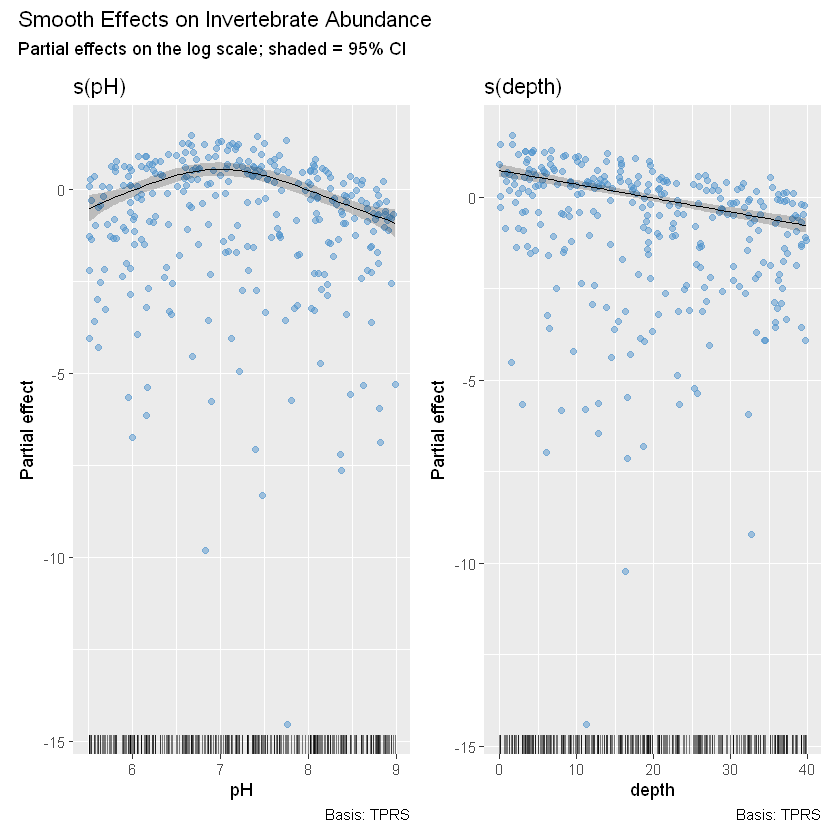

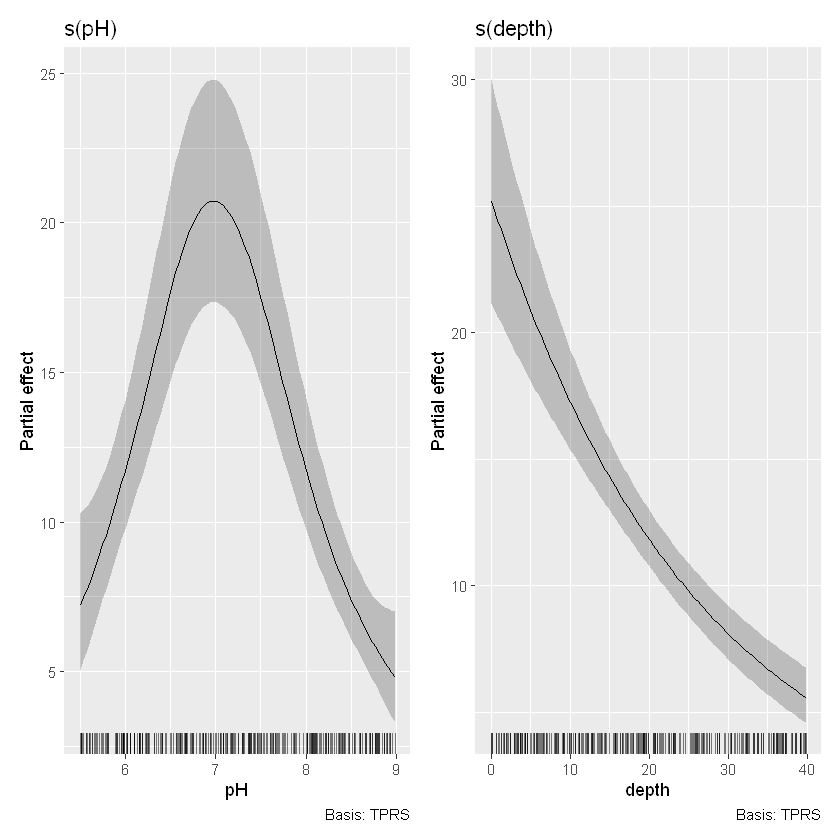

In [10]:
# ── Select specific smooths ───────────────────────────────────────────────────
# draw() returns a patchwork — unwrap to a plain ggplot using [[1]]
p_ph    <- gratia::draw(gam_eco, select = "s(pH)",    residuals = TRUE)[[1]]
p_depth <- gratia::draw(gam_eco, select = "s(depth)", residuals = TRUE)[[1]]

# ── Customize with patchwork ──────────────────────────────────────────────────
(p_ph | p_depth) +
  patchwork::plot_annotation(
    title    = "Smooth Effects on Invertebrate Abundance",
    subtitle = "Partial effects on the log scale; shaded = 95% CI"
  )

# ── Shift smooths to response scale ──────────────────────────────────────────
gratia::draw(gam_eco, constant = coef(gam_eco)[1], fun = exp)

---

## Predicted Response Curves

For presentation, manually construct prediction grids to have full control over the plot.

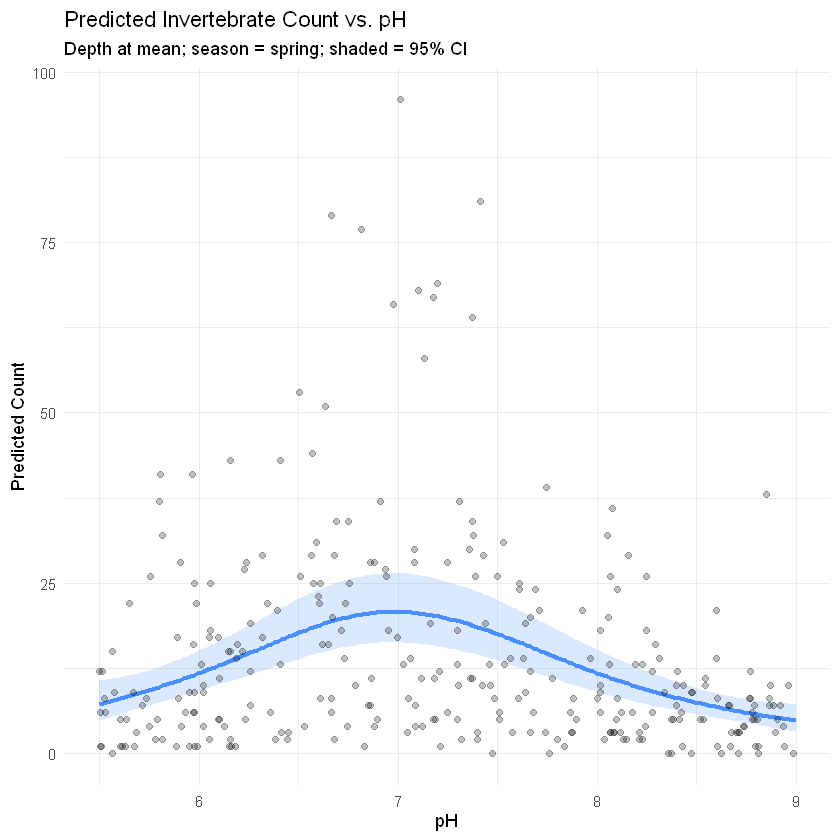

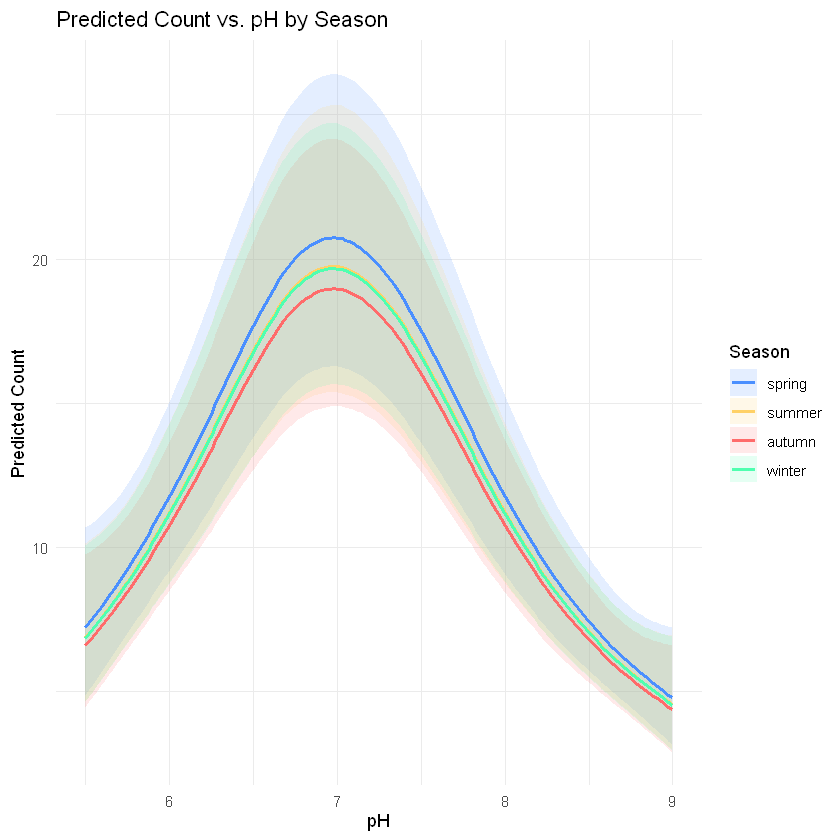

In [7]:
# ── Helper function: predict with CI ─────────────────────────────────────────
predict_gam_ci <- function(model, newdata, level = 0.95) {
  preds  <- predict(model, newdata = newdata, type = "link", se.fit = TRUE)
  z      <- qnorm((1 + level) / 2)
  newdata %>%
    mutate(
      fit   = exp(preds$fit),             # back-transform to response scale
      lower = exp(preds$fit - z * preds$se.fit),
      upper = exp(preds$fit + z * preds$se.fit)
    )
}

# ── Prediction over pH range ──────────────────────────────────────────────────
ph_grid <- expand.grid(
  pH     = seq(5.5, 9.0, length.out = 200),
  depth  = mean(eco_data$depth),
  season = "spring"   # hold at reference level
) %>% predict_gam_ci(model = gam_eco)

ggplot() +
  geom_ribbon(data = ph_grid,
              aes(x = pH, ymin = lower, ymax = upper),
              alpha = 0.2, fill = "#4a8fff") +
  geom_line(data = ph_grid, aes(x = pH, y = fit),
            color = "#4a8fff", linewidth = 1.2) +
  geom_point(data = eco_data,
             aes(x = pH, y = count),
             alpha = 0.25, size = 1.5) +
  labs(title = "Predicted Invertebrate Count vs. pH",
       subtitle = "Depth at mean; season = spring; shaded = 95% CI",
       x = "pH", y = "Predicted Count") +
  theme_minimal()

# ── Predictions for each season ───────────────────────────────────────────────
season_grid <- expand.grid(
  pH     = seq(5.5, 9.0, length.out = 150),
  depth  = mean(eco_data$depth),
  season = levels(eco_data$season)
) %>% predict_gam_ci(model = gam_eco)

ggplot(season_grid, aes(x = pH, color = season, fill = season)) +
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.15, color = NA) +
  geom_line(aes(y = fit), linewidth = 1) +
  scale_color_manual(values = c("#4a8fff", "#ffd166", "#ff6b6b", "#4fffb0")) +
  scale_fill_manual(values  = c("#4a8fff", "#ffd166", "#ff6b6b", "#4fffb0")) +
  labs(title = "Predicted Count vs. pH by Season",
       x = "pH", y = "Predicted Count", color = "Season", fill = "Season") +
  theme_minimal()

---

## Derivatives of Smooths

`gratia::derivatives()` computes the first derivative of a smooth — the instantaneous rate of change. This is useful for identifying where the response is increasing vs. decreasing and locating peaks and troughs with uncertainty.

ERROR: [1m[33mError[39m in `filter()`:[22m
[1m[22m[36mℹ[39m In argument: `.lower > 0 | .upper < 0`.
[1mCaused by error:[22m
[33m![39m object '.lower' not found


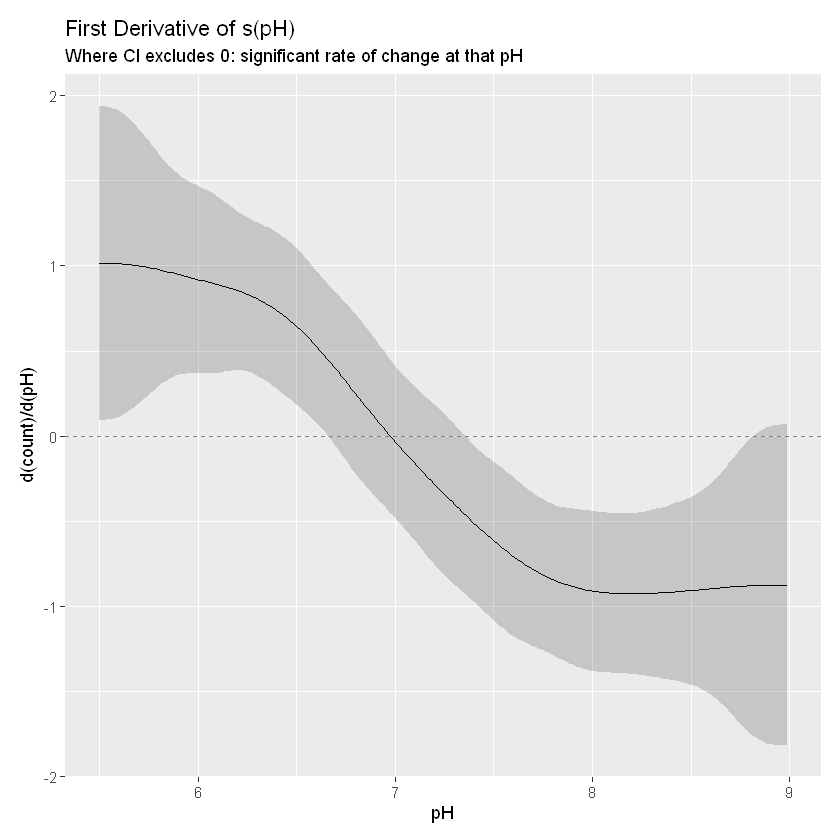

In [12]:
# ── First derivative of s(pH) ─────────────────────────────────────────────────
deriv_pH <- gratia::derivatives(
  gam_eco,
  term  = "s(pH)",   # must match the smooth label exactly, not just the variable
  order = 1,
  n     = 200
)

# ── Plot derivative with CI ───────────────────────────────────────────────────
gratia::draw(deriv_pH) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  labs(title = "First Derivative of s(pH)",
       subtitle = "Where CI excludes 0: significant rate of change at that pH",
       x = "pH", y = "d(count)/d(pH)")

# ── Identify significant change regions ──────────────────────────────────────
deriv_pH %>%
  filter(.lower > 0 | .upper < 0) %>%
  summarise(min_pH = min(.data),
            max_pH = max(.data),
            direction = ifelse(mean(.derivative) > 0, "increasing", "decreasing"))

---

## Simultaneous Confidence Bands

Pointwise CIs (the default in `draw()`) have 95% coverage at each individual point. **Simultaneous CIs** have 95% coverage across the entire smooth — more conservative and appropriate when making inferences about the curve as a whole.

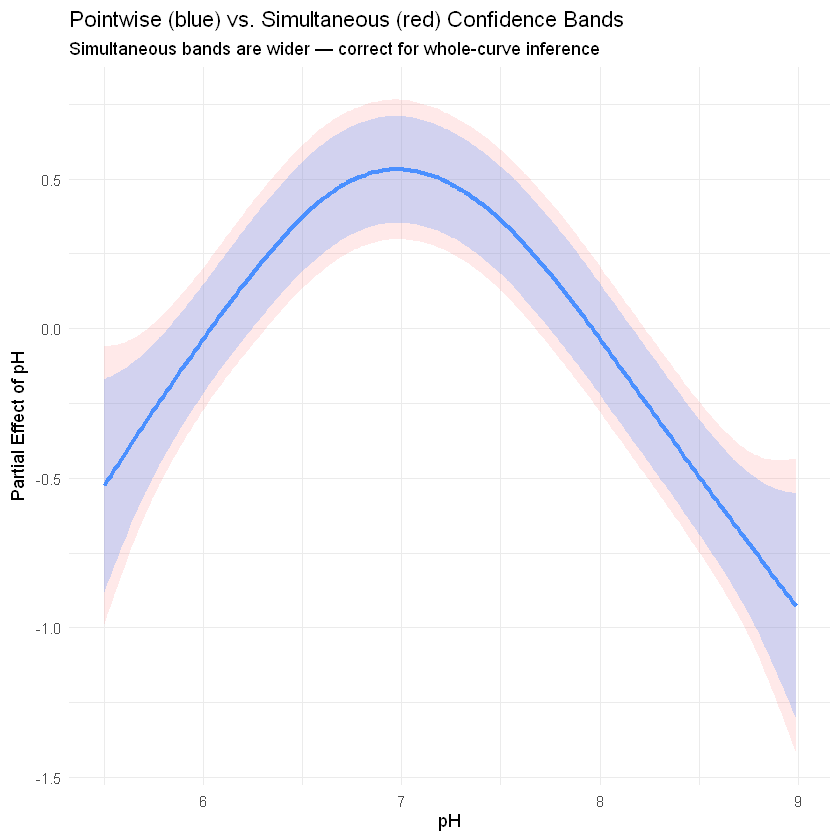

In [14]:
# ── Simultaneous CI via posterior simulation ──────────────────────────────────

# call via the base generic; gratia registers the S3 method
sim_ci <- confint(
  gam_eco,
  parm  = "s(pH)",
  level = 0.95,
  type  = "simultaneous",
  nsim  = 10000,
  seed  = 42,
  n     = 200
)

pointwise_ci <- confint(
  gam_eco,
  parm = "s(pH)",
  type = "confidence",
  n    = 200
)

# Also fix smooth_samples(): term -> select
smooth_samples <- gratia::smooth_samples(
  gam_eco,
  select = "s(pH)",   # term= is deprecated, use select=
  n      = 10000,
  seed   = 42
)

# ── Plot comparison: pointwise vs. simultaneous ───────────────────────────────
ggplot() +
  geom_ribbon(data = sim_ci,
              aes(x = pH, ymin = .lower_ci, ymax = .upper_ci),
              alpha = 0.15, fill = "#ff6b6b") +
  geom_ribbon(data = pointwise_ci,
              aes(x = pH, ymin = .lower_ci, ymax = .upper_ci),
              alpha = 0.25, fill = "#4a8fff") +
  geom_line(data = pointwise_ci,
            aes(x = pH, y = .estimate),
            linewidth = 1.2, color = "#4a8fff") +
  labs(title = "Pointwise (blue) vs. Simultaneous (red) Confidence Bands",
       subtitle = "Simultaneous bands are wider — correct for whole-curve inference",
       x = "pH", y = "Partial Effect of pH") +
  theme_minimal()

---

## Comparing Smooths: `difference_smooths()`

When a model has factor-smooth interactions, `difference_smooths()` computes the pairwise difference between group smooths with a CI. This directly answers: "at what values of x does the smooth for group A differ significantly from group B?"

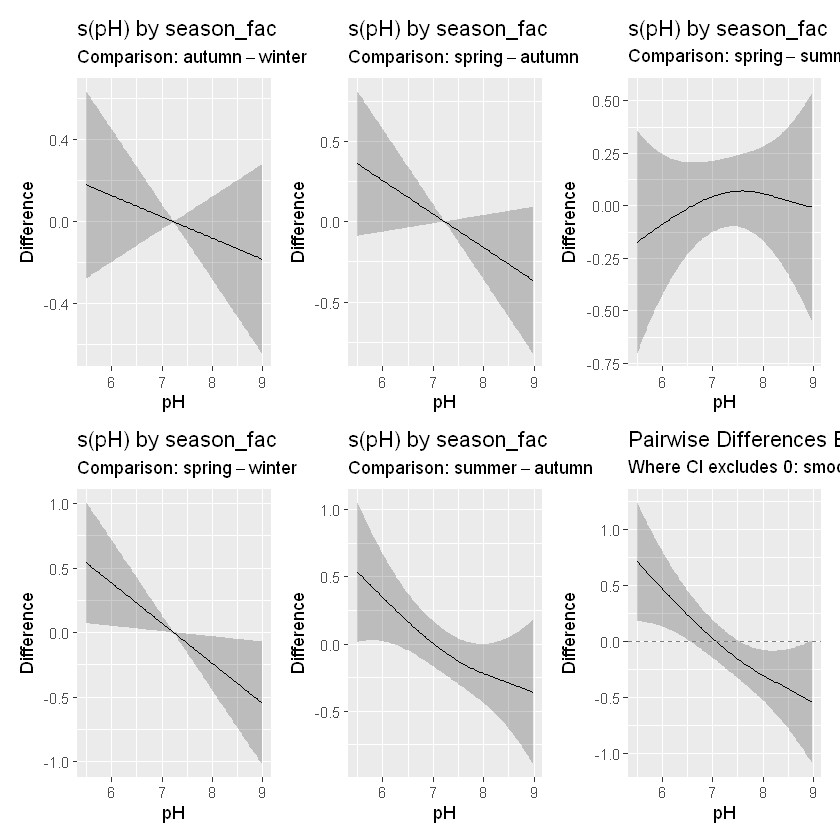

In [16]:
# ── Use unordered factor for by= smooths ─────────────────────────────────────
# difference_smooths() requires unordered factor — ordered factors use
# polynomial contrasts which produce non-conformable prediction matrices
eco_data2 <- eco_data %>%
  mutate(season_fac = factor(season,
                             levels = c("spring", "summer", "autumn", "winter"),
                             ordered = FALSE))   # unordered

gam_fs <- mgcv::gam(
  count ~ season_fac +
          s(pH, bs = "tp") +
          s(pH, by = season_fac, bs = "tp") +   # unordered factor
          s(depth),
  data   = eco_data2,
  family = mgcv::nb(),
  method = "REML"
)

# ── Difference between smooths ────────────────────────────────────────────────
diffs <- gratia::difference_smooths(
  gam_fs,
  select   = "s(pH)",   # select= replaces deprecated smooth=
  ci_level = 0.95
)

gratia::draw(diffs) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  labs(title = "Pairwise Differences Between Seasonal pH Smooths",
       subtitle = "Where CI excludes 0: smooth shapes differ significantly at that pH")

---

## Common Pitfalls

**1. Plotting smooths on the link scale and calling them the response**  
By default, `draw()` shows partial effects on the link scale, centered at zero. For a log-link model, these are log-count effects — not counts. Use `transform = exp` and `shift = coef(model)[1]` to shift to the response scale.

**2. Using pointwise CIs for whole-curve inference**  
Pointwise CIs describe uncertainty at individual x values. If you want to make statements about the entire curve (e.g., "the peak is significantly above zero"), use simultaneous CIs from `gratia::confint(type = "simultaneous")`.

**3. Not showing the data alongside the smooth**  
A smooth plotted without the underlying data gives no sense of data density, extrapolation regions, or potential outliers. Always add partial residuals or raw data to smooth plots.

**4. Not plotting derivatives when interested in rates of change**  
The smooth itself shows the effect — the derivative shows where the effect is changing significantly. For questions like "at what pH does density start declining?", `gratia::derivatives()` gives a rigorous answer.

**5. Using base R `plot.gam()` for publications**  
`mgcv`'s base graphics plots are functional for exploration but difficult to customize. `gratia::draw()` returns ggplot objects that can be modified with standard ggplot2 syntax.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*